# Preamble

In [1]:
%%HTML 
<style>
body {
    max-width: 100%;
    margin-left: 5%;
    margin-right: 40%;
}
</style>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson
from cycler import cycler


# --- Scientific Presentation Style ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2.5,
    'figure.figsize': (10, 6),
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "legend.fontsize": 12,
    "legend.frameon": False,
})

muted_tab10 = [
    "#73A0BD",  # blue
    "#EEA461",  # orange
    "#7AB672",  # green
    "#D77470",  # red
    "#B397C2",  # purple
    "#AF8E83",  # brown
    "#DEA0C4",  # pink
    "#A8A49F",  # gray
    "#C9C66C",  # olive
    "#6EC7CB",  # cyan
]

plt.rcParams["axes.prop_cycle"] = cycler(color = muted_tab10)


# Parameters

In [ ]:
# physical constants
c       = 3e8                    # speed of light [m/s]
k_B     = 8.617333262145e-5      # Boltzmann constant [eV/K]
hbar    = 6.582119569e-16        # Reduced Planck constant [eV*s]
m_e     = 5.485e-4               # electron mass [eV*(s/m)^2]

# material constants
E_F     = 5.0                    # Chemical potential [eV]
T_F     = E_F/k_B                # Fermi temperature [K]

# system constants
T_e     = 300                    # electron system temperature [K]
E_L     = 2.25                   # pump photon energy [eV]
EF_L    = 5e10                   # pump field strength [V^2/m^2]
EF_sat  = 1e13                   # saturation field [V^2/m^2]
delta_E = (EF_L/EF_sat)**2       # non-equilibrium factor [a.u.]

# Helper Functions

In [4]:
# Relative Error
def rel_error(ref, test):
    ref = np.asarray(ref)
    test = np.asarray(test)
    rel = np.abs((ref - test) / ref)

    return np.clip(rel, 1e-16, 1.0)

# Bose-Einstein distribution
def n_BE(hw):
    beta = 1 / (k_B * T_e)
    return 1 / np.expm1(beta * hw)

# Black Body Spectrum
def E_BB(hw):
    return hw * n_BE(hw)

# Photonic Contribution to Emission
def I_ph(hw):
    '''
    photonic density of states
    
    :param hw: emission (photon) energy [ev]
    '''
    return

# Main Functions

<!-- **Electronic density of states**

$$ \rho_e(\mathcal{E}) = \frac{{m_e}^{3/2}}{\pi^2\hbar^3}\sqrt{2\mathcal{E}} $$

**Fermi-Dirac distribution**

$$ f^{T}(\mathcal{E}) = \frac{1}{\exp\Big(\frac{\mathcal{E}-\mu}{k_{B}T}\Big)+1} $$

**Chemical potential (first-order in $T/T_F$)**

$$ \mu(T) = \mathcal{E}_{\scriptsize F}\left[1- \frac{\pi^{2}}{12}\left( \frac{T}{T_{\scriptsize F}} \right)^{2}\right] $$ -->



In [5]:
# parabolic conduction band eDOS
def g_c(E):
    return ( ((m_e)**(3/2)) / ((np.pi**2)*(hbar**3)) )*np.sqrt(2*E)

def g_const(E):
    return g_c(E_F)

# def g_c_X(E)
# def g_c_L(E)
# def g_v_X(E)
# def g_v_L(E)

# Thermal distribution
def f_T(E):
    C = ((np.pi**2)/12)
    # chemical potential for fermi gas with T << T_F in 3D
    mu = E_F*( 1 - C*((T_e/T_F)**2))
    return 1 / (np.exp((E - mu) / (k_B * T_e)) + 1)

# Steady-state distribution
def f_S(E):
    A = f_T(E - E_L) * (1 - f_T(E))
    B = f_T(E) * (1 - f_T(E + E_L))
    return f_T(E) + delta_E*(A-B)

# Stable thermal factor (avoids 1 - f cancellation)
def F_T(E, hw):
    beta = 1 / (k_B * T_e)
    C = ((np.pi**2)/12)
    mu = E_F*( 1 - C*((T_e/T_F)**2))
    a1 = beta * (E + hw - mu)
    a2 = beta * (E - mu)
    return np.exp(a2 - np.logaddexp(0.0, a2) - np.logaddexp(0.0, a1))

# Statistical factor
def F(E, hw, dist):
    '''
    Statistical Factor
    
    :param E:    energy integration variable [ev]
    :param hw:   emission energy [ev]
    :param dist: electronic distribution f(E)
    '''
    if dist is f_T:
        return F_T(E, hw)
    return dist(E + hw) * (1 - dist(E))

# Jacobian
def J(E, hw, eDOS1, eDOS2):
    '''
    Jacobian - determined by dispersion relation
    
    :param E:     energy integration variable [ev]
    :param hw:    emission energy [ev]
    :param eDOS1: initial electronic density of states g(E)
    :param eDOS1: final electronic density of states g(E)
    '''
    return eDOS1(E + hw) * eDOS2(E)

# Integrand
def integrand(E, hw, dist, eDOS1, eDOS2):
    '''
    Integrand
    
    :param E:    energy integration variable [ev]
    :param hw:   emission energy [ev]
    :param dist: electronic density of states g(E)
                 determines whether we're in a thermal,
                 steady-state or pulsed scenario.
    :param eDOS: electronic density of states g(E)
                 depends on whether we're using a
                 parabolic, quadratic, intra or interband transitions
    '''
    return F(E, hw, dist) * J(E, hw, eDOS1, eDOS2)

# Emission
# Ei = Ef + hw
# Ei - Ef - hw   = 0
# Ei - (Ef + hw) = 0

def I_e(E_list, hw_list, dist, eDOS1, eDOS2):
    '''
    electronic contribution to emission
    
    :param E_list:  integration interval
    :param hw_list: hw points over which the integral is computed
    '''
    result = []
    for hw in hw_list:
        integral = simpson(integrand(E_list, hw, dist, eDOS1, eDOS2), E_list)
        result.append(integral)

    return result

# exact thermal intraband emission constant eDOS
def I_e_exact_T(hw_list, eDOS):
    beta = 1 / (k_B * T_e)
    mu = E_F*( 1 - ((np.pi**2)/12)*((T_e/T_F)**2))
    A = (eDOS(E_F)**2)  * n_BE(hw_list)
    log1pa = np.logaddexp(0.0, -beta * mu)
    log1pb = np.logaddexp(0.0, beta * (hw_list - mu))
    return A * (hw_list + (log1pa - log1pb) / beta)

# approximaete thermal intraband emission constant eDOS
def I_e_approx_T(hw_list, eDOS):
    return (eDOS(E_F)**2) * hw_list * n_BE(hw_list)

# approximaete steady-state intraband emission constant eDOS
def I_e_approx_S(hw_list, eDOS):
    A = 2*E_BB(hw_list - E_L)
    B = -2*E_BB(hw_list - E_L) + E_BB(hw_list - 2*E_L)
    return (eDOS(E_F)**2) * (E_BB(hw_list) + delta_E*A + delta_E*delta_E*B)


# Numeric Convergence
## Step Size Convergence

<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
/var/folders/8_/lb82j87n40q1pn140s68mgz80000gn/T/ipykernel_63711/2660933425.py:23: SyntaxWarning: invalid escape sequence '\l'
  axes[i].set_ylabel('$\log_{10}(\delta_{rel})$')


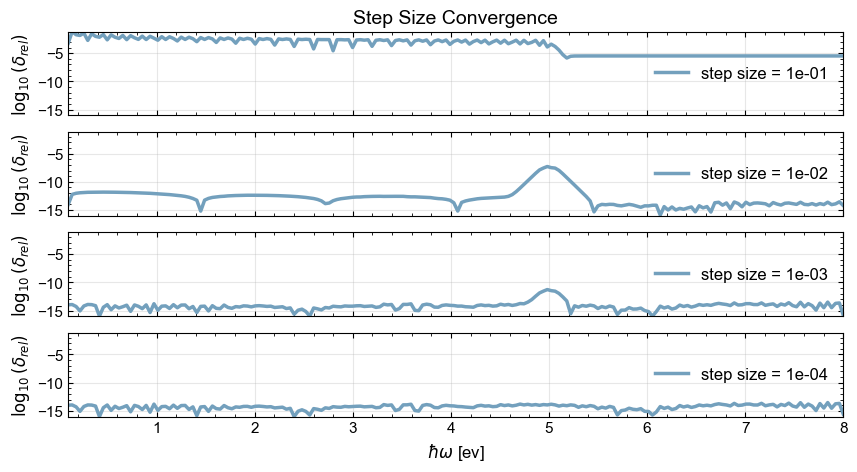

In [6]:
hw_list = np.linspace(0.1, 8.0, 200)
I_intra_exact_T = I_e_exact_T(hw_list, g_const)
step_sizes = [1e-1, 1e-2, 1e-3, 1e-4]
fig, axes = plt.subplots(nrows=len(step_sizes), ncols=1, figsize=(10.0, 5.0), sharex=True)

all_log_err = []
for step_size in step_sizes:
    E_list = np.arange(0.0, 10.0, step_size)
    I_intra_parabolic_T = I_e(E_list, hw_list, f_T, g_const, g_const)
    relative_error = rel_error(I_intra_exact_T, I_intra_parabolic_T)
    all_log_err.append(np.log10(relative_error))

finite_vals = np.concatenate([arr[np.isfinite(arr)] for arr in all_log_err])
ymin = finite_vals.min()
ymax = finite_vals.max()

for i, step_size in enumerate(step_sizes):
    axes[i].plot(hw_list, all_log_err[i], label=f'step size = {step_size:.0e}')
    axes[i].set_ylim(ymin, ymax)
    axes[i].set_xlim(hw_list[0], hw_list[-1])
    axes[i].legend(loc = 'right')
    axes[i].set_facecolor("none")
    axes[i].set_ylabel('$\log_{10}(\delta_{rel})$')

axes[-1].set_xlabel(r'$\hbar\omega$ [ev]')
axes[0].set_title('Step Size Convergence')

fig.patch.set_alpha(0)
# plt.savefig("/Users/ben/Projects/metal_photoluminescence/docs/4 Misc/Attachments/step_size_convergence.png", dpi=300, transparent=True, bbox_inches="tight")

## Integration Interval Convergence

<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
/var/folders/8_/lb82j87n40q1pn140s68mgz80000gn/T/ipykernel_63711/106937323.py:23: SyntaxWarning: invalid escape sequence '\l'
  axes[i].set_ylabel('$\log_{10}(\delta_{rel})$')


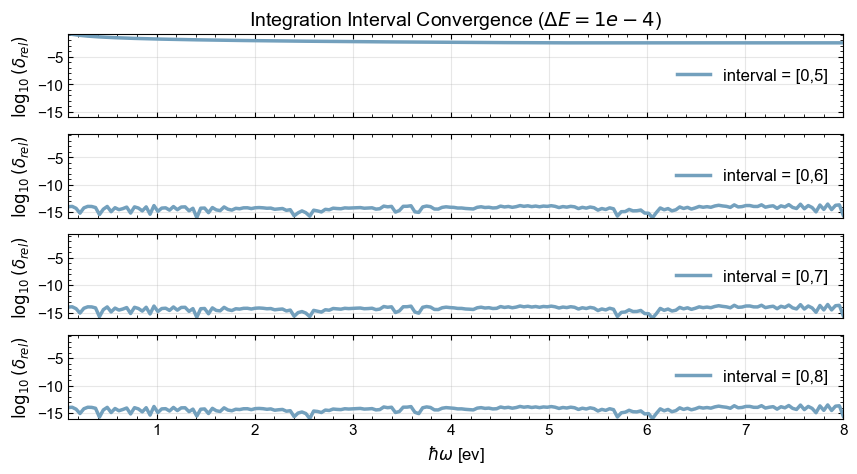

In [7]:
hw_list = np.linspace(0.1, 8.0, 200)
I_intra_exact_T = I_e_exact_T(hw_list, g_const)
interval_length = [5,6,7,8]
fig, axes = plt.subplots(nrows=len(interval_length), ncols=1, figsize=(10.0, 5.0), sharex=True)

all_log_err = []
for L in interval_length:
    E_list = np.arange(0.0, L, 1e-4)
    I_intra_parabolic_T = I_e(E_list, hw_list, f_T, g_const, g_const)
    relative_error = rel_error(I_intra_exact_T, I_intra_parabolic_T)
    all_log_err.append(np.log10(relative_error))

finite_vals = np.concatenate([arr[np.isfinite(arr)] for arr in all_log_err])
ymin = finite_vals.min()
ymax = finite_vals.max()

for i, L in enumerate(interval_length):
    axes[i].plot(hw_list, all_log_err[i], label=f'interval = [0,{L}]')
    axes[i].set_ylim(ymin, ymax)
    axes[i].set_xlim(hw_list[0], hw_list[-1])
    axes[i].legend(loc = 'right')
    axes[i].set_facecolor("none")
    axes[i].set_ylabel('$\log_{10}(\delta_{rel})$')

axes[-1].set_xlabel(r'$\hbar\omega$ [ev]')
axes[0].set_title(r'Integration Interval Convergence ($\Delta E = 1e-4$)')

fig.patch.set_alpha(0)
# plt.savefig("/Users/ben/Projects/metal_photoluminescence/docs/4 Misc/Attachments/interval_length_convergence.png", dpi=300, transparent=True, bbox_inches="tight")

## Analytic Approximations VS Numeric Constant eDOS

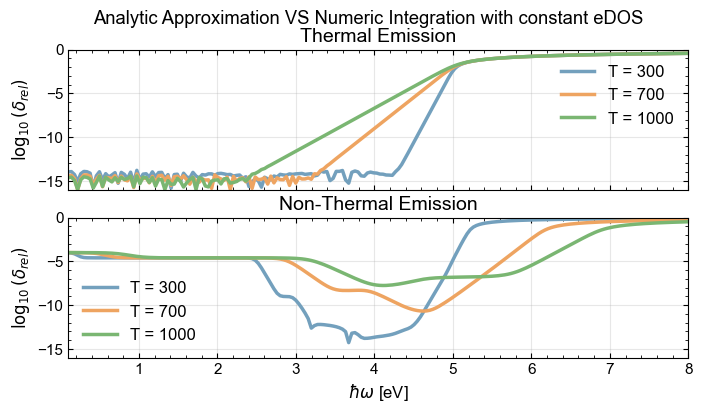

In [8]:
E_list = np.linspace(0.0,10.0,100000)
hw_list = np.linspace(0.1, 8.0, 200)

fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(8.0, 4.0), sharex=True)
for T_e in [300, 700, 1000]:
    I_intra_parabolic_T = I_e(E_list, hw_list, f_T, g_const, g_const)
    I_intra_parabolic_S = I_e(E_list, hw_list, f_S, g_const, g_const)
    I_intra_approx_T    = I_e_approx_T(hw_list, g_const)
    I_intra_approx_S    = I_e_approx_S(hw_list, g_const)

    rel_T = rel_error(I_intra_approx_T, I_intra_parabolic_T)
    rel_S = rel_error(I_intra_approx_S, I_intra_parabolic_S)
    axes[0].plot(hw_list, np.log10(rel_T), label = f'T = {T_e}')
    axes[1].plot(hw_list, np.log10(rel_S), label = f'T = {T_e}')

for ax in axes:
    ax.set_xlim(hw_list[0], hw_list[-1])
    ax.set_ylim(-16,0)
    ax.legend()
ax.set_xlabel(r'$\hbar\omega$ [eV]')

# fig.suptitle(r'Analytic Approximations')
axes[0].set(title = 'Thermal Emission', ylabel = '$\\log_{10}(\\delta_{rel})$');
axes[1].set(title = 'Non-Thermal Emission', ylabel = '$\\log_{10}(\\delta_{rel})$');

fig.patch.set_alpha(0)
fig.suptitle(r'Analytic Approximation VS Numeric Integration with constant eDOS');
# plt.savefig("/Users/ben/Projects/metal_photoluminescence/docs/4 Misc/Attachments/analytic_approximations.png", dpi=300, transparent=True, bbox_inches="tight")

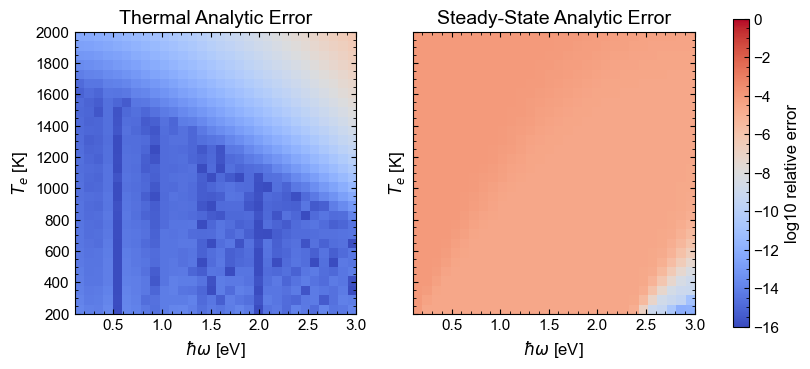

In [9]:
N = 30
im_T = np.zeros((N, N))
im_S = np.zeros((N, N))
hw_list = np.linspace(0.1, 3.0, N)
T_e_list = np.linspace(200, 2000, N)

for i, T_e in enumerate(T_e_list):
    I_ref_T = np.array(I_e(E_list, hw_list, f_T, g_const, g_const))
    I_approx_T = I_e_approx_T(hw_list, g_const)
    I_ref_S = np.array(I_e(E_list, hw_list, f_S, g_const, g_const))
    I_approx_S = I_e_approx_S(hw_list, g_const)

    rel_T = np.log10(np.clip(rel_error(I_ref_T, I_approx_T), 1e-16, None))
    rel_S = np.log10(np.clip(rel_error(I_ref_S, I_approx_S), 1e-16, None))
    im_T[i, :] = rel_T
    im_S[i, :] = rel_S

fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(10.0, 4.0), sharey=True, subplot_kw={"box_aspect": 1})
m0 = axes[0].imshow(
    im_T, origin="lower", aspect="auto",
    extent=[hw_list[0], hw_list[-1], T_e_list[0], T_e_list[-1]],
    cmap="coolwarm", vmin=-16, vmax=0
)
m1 = axes[1].imshow(
    im_S, origin="lower", aspect="auto",
    extent=[hw_list[0], hw_list[-1], T_e_list[0], T_e_list[-1]],
    cmap="coolwarm", vmin=-16, vmax=0
)

axes[0].set_title('Thermal Analytic Error')
axes[1].set_title('Steady-State Analytic Error')

for ax in axes:
    ax.set(xlabel=r'$\hbar\omega$ [eV]', ylabel=r'$T_e$ [K]')
    ax.grid(False)
fig.colorbar(m0, ax=axes, label="log10 relative error",)
fig.patch.set_alpha(0)
plt.savefig("/Users/ben/Projects/metal_photoluminescence/docs/4 Misc/Attachments/analytic_error_heatmaps.png", dpi=300, transparent=True, bbox_inches="tight")
# plt.savefig("C:\\Users\\Bensh1\\Projects\\metal_photoluminescence\\docs\\4 Misc\\Attachments\\analytic_error_heatmaps.png", dpi=300, transparent=True, bbox_inches="tight")

# Variable VS Constant eDOS

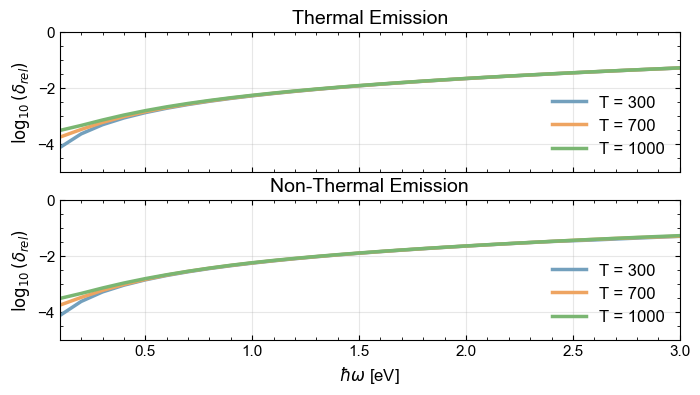

In [10]:
fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(8.0, 4.0), sharex=True)
for T_e in [300, 700, 1000]:
    I_intra_const_T = I_e(E_list, hw_list, f_T, g_const, g_const)
    I_intra_const_S = I_e(E_list, hw_list, f_S, g_const, g_const)
    I_intra_var_T   = I_e(E_list, hw_list, f_T, g_c, g_c)
    I_intra_var_S   = I_e(E_list, hw_list, f_S, g_c, g_c)

    rel_T = rel_error(I_intra_var_T, I_intra_const_T)
    rel_S = rel_error(I_intra_var_S, I_intra_const_S)
    axes[0].plot(hw_list, np.log10(rel_T), label = f'T = {T_e}')
    axes[1].plot(hw_list, np.log10(rel_S), label = f'T = {T_e}')

for ax in axes:
    ax.set_xlim(hw_list[0], hw_list[-1])
    ax.set_ylim(-5,0)
    ax.legend()
ax.set_xlabel(r'$\hbar\omega$ [eV]')

# fig.suptitle(r'Constant eDOS approximation')

axes[0].set(title = 'Thermal Emission', ylabel = '$\\log_{10}(\\delta_{rel})$');
axes[1].set(title = 'Non-Thermal Emission', ylabel = '$\\log_{10}(\\delta_{rel})$');

fig.patch.set_alpha(0)
plt.savefig("/Users/ben/Projects/metal_photoluminescence/docs/4 Misc/Attachments/constant_eDOS_approximation.png", dpi=300, transparent=True, bbox_inches="tight")
# plt.savefig("C:\\Users\\Bensh1\\Projects\\metal_photoluminescence\\docs\\4 Misc\\Attachments\\constant_eDOS_approximation.png", dpi=300, transparent=True, bbox_inches="tight")

/var/folders/8_/lb82j87n40q1pn140s68mgz80000gn/T/ipykernel_63711/1023486282.py:18: RuntimeWarning: overflow encountered in exp
  return 1 / (np.exp((E - mu) / (k_B * T_e)) + 1)


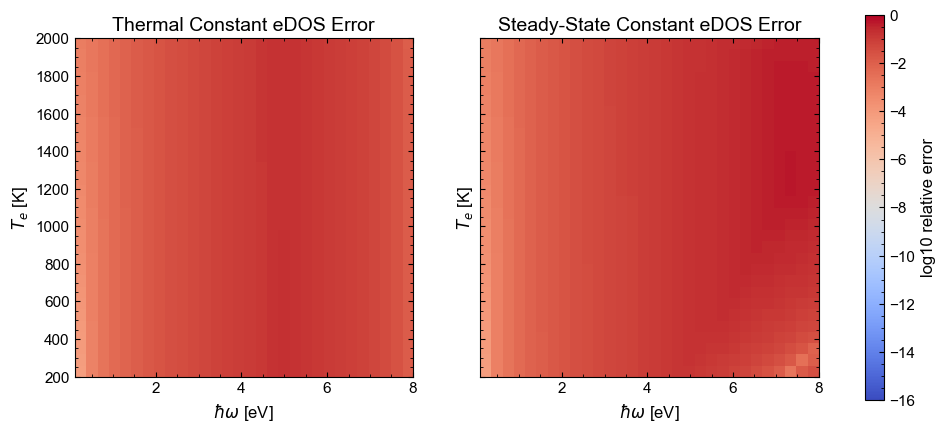

In [11]:
N = 30
im_T = np.zeros((N, N))
im_S = np.zeros((N, N))
hw_list = np.linspace(0.1, 8.0, N)
T_e_list = np.linspace(200, 2000, N)

for i, T_e in enumerate(T_e_list):
    I_ref_T   = np.array(I_e(E_list, hw_list, f_T, g_c, g_c))
    I_const_T = np.array(I_e(E_list, hw_list, f_T, g_const, g_const))
    I_ref_S   = np.array(I_e(E_list, hw_list, f_S, g_c, g_c))
    I_const_S = np.array(I_e(E_list, hw_list, f_S, g_const, g_const))



    rel_T = np.log10(np.clip(rel_error(I_ref_T, I_const_T), 1e-16, None))
    rel_S = np.log10(np.clip(rel_error(I_ref_S, I_const_S), 1e-16, None))
    im_T[i, :] = rel_T
    im_S[i, :] = rel_S

fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(12.0, 5.0), sharey=True)
m0 = axes[0].imshow(
    im_T, origin="lower", aspect="auto",
    extent=[hw_list[0], hw_list[-1], T_e_list[0], T_e_list[-1]],
    cmap="coolwarm", vmin=-16, vmax=0
)
m1 = axes[1].imshow(
    im_S, origin="lower", aspect="auto",
    extent=[hw_list[0], hw_list[-1], T_e_list[0], T_e_list[-1]],
    cmap="coolwarm", vmin=-16, vmax=0
)

axes[0].set_title('Thermal Constant eDOS Error')
axes[1].set_title('Steady-State Constant eDOS Error')

for ax in axes:
    ax.set(xlabel=r'$\hbar\omega$ [eV]', ylabel=r'$T_e$ [K]')
    ax.set_box_aspect(1)
    ax.grid(False)
fig.colorbar(m0, ax=axes, label="log10 relative error")
plt.savefig("/Users/ben/Projects/metal_photoluminescence/docs/4 Misc/Attachments/constant_eDOS_heatmap.png", dpi=300, transparent=True, bbox_inches="tight")
# plt.savefig("C:\\Users\\Bensh1\\Projects\\metal_photoluminescence\\docs\\4 Misc\\Attachments\\consteDOS_error_heatmaps.png", dpi=300, transparent=True, bbox_inches="tight")

### Gaussian Delta Approximation (Double Integral)

We approximate the energy conservation delta function $\delta(E_1 - E_2 - \hbar\omega)$ with a Gaussian $G_\sigma(x)$ of width $\sigma$.
To optimize performance, the integration over the energy difference $u = E_1 - E_2 - \hbar\omega$ is restricted to a window $[-M\sigma, M\sigma]$ with $N$ steps within $2\sigma$: 

$$ I(\hbar\omega) \approx \int \rho(\mathcal{E}_1)f(\mathcal{E}_1) \left[ \int_{-M\sigma}^{M\sigma} \rho(\mathcal{E}') [1-f(\mathcal{E}')] G_\sigma(u) \, du 
\right] d\mathcal{E}_1 $$

where $\mathcal{E}' = \mathcal{E}_1 - \hbar\omega - u$. The parameters $M$ and $N$ allow tuning the balance between accuracy and computational cost.


<>:64: SyntaxWarning: invalid escape sequence '\s'
<>:64: SyntaxWarning: invalid escape sequence '\s'
/var/folders/8_/lb82j87n40q1pn140s68mgz80000gn/T/ipykernel_63711/1178398319.py:64: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(hw_vals, np.log10(delta), 'o-', markersize=4, label=f'Gaussian Integral ($\sigma$={sigma_val:.0e})')


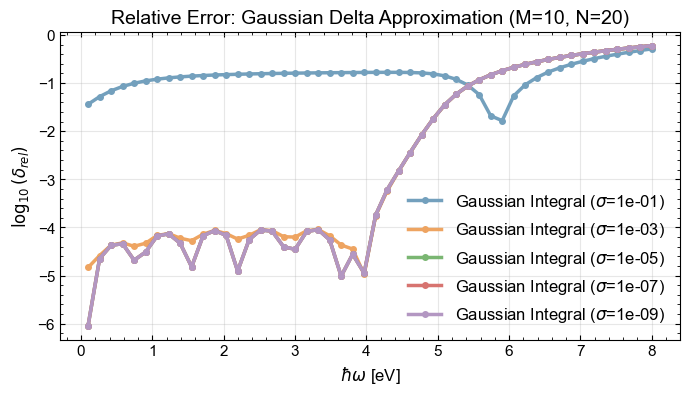

<Figure size 1000x600 with 0 Axes>

In [12]:
def I_double_integral_gaussian(E, hw_target, sigma, dist, eDOS, M=5, N=20):
    '''
    Computes emission I(hw) via double integration over E1 and E2 using a Gaussian delta.
    Optimized to integrate only over the relevant Gaussian window [-M*sigma, M*sigma].
    
    Parameters:
    - M: Integration window half-width in units of sigma.
    - N: Number of grid points per 2*sigma interval.
    '''
    
    # 1. Setup local grid u for the Gaussian difference
    u_max = M * sigma
    du = (2 * sigma) / N
    u = np.arange(-u_max, u_max + du/2, du)

    
    # Gaussian function G(u)
    G_u = (1.0 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * (u / sigma)**2)
    
    # 2. Precompute state densities on the main grid E
    # rho_occ(E) = g(E) * f(E)
    # rho_vac(E) = g(E) * (1 - f(E))
    rho_occ = eDOS(E) * dist(E)
    rho_vac_func = lambda e: eDOS(e) * (1 - dist(e))
    
    # Interpolation helper: map energies to rho_vac, 0 if out of bounds
    # We precompute rho_vac on E for fast interpolation
    rho_vac_vals = rho_vac_func(E)

    spectrum = []
    for hw in hw_target:
        # Construct the matrix of E' = E1 - hw - u
        # Shape: (len(E), len(u))
        E_prime = E[:, None] - hw - u[None, : ]
        
        # Interpolate rho_vac at E'
        # np.interp works on 1D, so we flatten and reshape
        rho_vac_interp = np.interp(E_prime.ravel(), E, rho_vac_vals, left=0, right=0)
        rho_vac_interp = rho_vac_interp.reshape(E_prime.shape)
        
        # Inner Integral: integral( rho_vac(E') * G(u) du )
        inner_integral = simpson(rho_vac_interp * G_u[None, :], x=u, axis=1)
        
        # Outer Integral: integral( rho_occ(E1) * inner_result dE1 )
        total_rate = simpson(rho_occ * inner_integral, x=E)
        spectrum.append(total_rate)

    return np.array(spectrum)

# --- Execution & Verification ---
E_grid = np.linspace(0, 10.0, 2000)
hw_vals = np.linspace(0.1, 8.0, 50)
sigma_val = 0.1
N = 20
M = 10

plt.figure(figsize=(8, 4))
for sigma_val in [1e-1, 1e-3, 1e-5, 1e-7, 1e-9]:
    I_gauss = I_double_integral_gaussian(E_grid, hw_vals, sigma_val, f_T, g_const, M=M, N=N)
    I_ref   = I_e_exact_T(hw_vals, g_const)
    delta   = rel_error(I_ref, I_gauss)


    plt.plot(hw_vals, np.log10(delta), 'o-', markersize=4, label=f'Gaussian Integral ($\sigma$={sigma_val:.0e})')
    plt.xlabel(r'$\hbar\omega$ [eV]')
    plt.ylabel(r'$\log_{10}(\delta_{rel})$')
    plt.title(f'Relative Error: Gaussian Delta Approximation (M={M}, N={N})')
    plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
plt.savefig("/Users/ben/Projects/metal_photoluminescence/docs/4 Misc/Attachments/gaussian_delta_convergence.png", dpi=300, transparent=True, bbox_inches="tight")

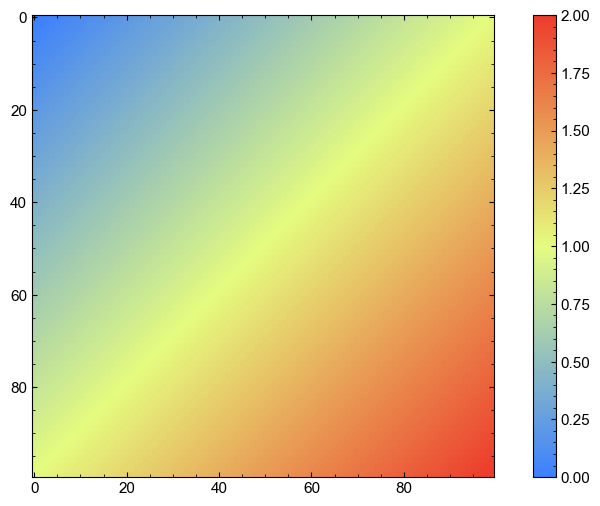

In [13]:
import numpy as np
import matplotlib.colors as mcolors

def muted_coldhot(c0="#3B80FF", c1="#ED3C2C", mid="#E5FC7F", N=256):
    # mid is a muted warm tan (helps the perceptual "warming" in the center)
    return mcolors.LinearSegmentedColormap.from_list(
        "muted_coldhot", [c0, mid, c1], N=N
    )

cmap = muted_coldhot()
x,y = np.meshgrid(np.linspace(0,1,100), np.linspace(0,1,100))
data = x+y
plt.imshow(data, cmap=cmap); plt.colorbar()
plt.grid(False)